(array([ 0.4968582 , -1.00760256]),
 np.float64(0.019953841027538298),
 np.float64(0.02334513016107684))

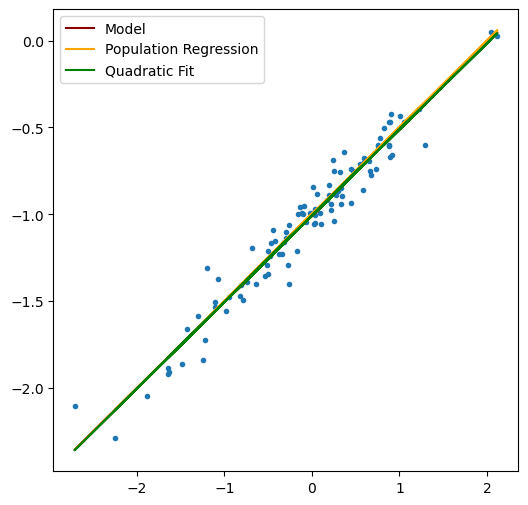

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

rng = np.random.default_rng(1)
x = rng.normal(0,1,100)

eps = rng.normal(0,0.1,100)

y_hat = -1 + 0.5 * x + eps 
y_hat_length = np.linalg.norm(y_hat)

fig, ax = plt.subplots(figsize=(6,6))
coef = np.polyfit(x,y_hat,1)
linreg = np.poly1d(coef)

y = -1 + 0.5 * x
ax.plot(x,y_hat,'o',markersize=3)
ax.plot(x,linreg(x),label='Model',color='darkred')
ax.plot(x,y,label='Population Regression',color='orange')

coef2 = np.polyfit(x,y_hat,2)
linreg2 = np.poly1d(coef2)
ax.plot(x,linreg2(x),label='Quadratic Fit',color='green')
ax.legend()

slope, intercept, r_value, p_value, s_beta1 = st.linregress(x,y_hat)
t_crit = st.t.ppf(0.975, df=len(x)-2)
confint_beta1 = t_crit * s_beta1
s_yx = s_beta1 * np.sqrt(np.var(x,ddof=1)*(len(x)-1))
s_beta0 = s_yx * np.sqrt(np.sum(x**2)/((len(x)-1)*len(x)*np.var(x,ddof=1)))
confint_beta0 = t_crit * s_beta0
coef, confint_beta0, confint_beta1
